#### Imports and Setups

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import time
from IPython.display import clear_output
from IPython.display import display
import csv
import os
from pathlib import Path
import numpy as np
from bs4 import BeautifulSoup
import requests



In [2]:
fig_dir = Path.cwd().parent / "outputs" / "figures" / "without_allias" 
fig_dir.mkdir(parents=True, exist_ok=True)

#### Loading Data

In [3]:
base_dir = Path.cwd().parent / "data" / "result" / "without_allias"

try:
    gTLD_summary_df = pd.read_parquet(base_dir / "gTLD_Dependency_summary_group")
    gTLD_unresolved_df = pd.read_parquet(base_dir / "gTLD_unresolved_group")
    
    ccTLD_summary_df = pd.read_parquet(base_dir / "ccTLD_Dependency_summary.parquet")
    ccTLD_unresolved_df = pd.read_parquet(base_dir / "ccTLD_unresolved.parquet")
    
    genTLD_summary_df = pd.read_parquet(base_dir / "gen-resTLD_Dependency_summary.parquet")
    genTLD_unresolved_df = pd.read_parquet(base_dir / "gen-resTLD_unresolved.parquet")
    
    infTLD_summary_df = pd.read_parquet(base_dir / "infTLD_Dependency_summary.parquet")
    infTLD_unresolved_df = pd.read_parquet(base_dir / "infTLD_unresolved.parquet")
    
    sponTLD_summary_df = pd.read_parquet(base_dir / "sponTLD_Dependency_summary.parquet")
    sponTLD_unresolved_df = pd.read_parquet(base_dir / "sponTLD_unresolved.parquet")
except Exception as e:
    print(f"failed: {e}")

In [4]:
sponTLD_unresolved_df.head()

,start_domain
0,yxlm5725287.hupunba.asia
1,vagwegatbf2r05.dmz.va.gov
2,net.ttu.edu
3,agriculture.wy.gov
4,yxlm5292192.hupunba.asia


In [5]:
len(gTLD_summary_df)

161728

In [6]:
# Drop duplicates from gTLD, duplicates formed due to chuck mode of processing. It was discoverd letter when the data was not tallying
gTLD_summary_df = gTLD_summary_df.drop_duplicates().copy()

In [7]:
len(gTLD_summary_df)

121133

In [9]:
base_dir = Path.cwd().parent / "data" / "names" 

try:
    categorized_names_df = pd.read_parquet(base_dir / "categorized_names.parquet")
except Exception as e:
    print(f"failed: {e}")

##### test to be locked at later 

In [11]:
gTLD_name_list = categorized_names_df[categorized_names_df["type"] == "generic"]["names"].tolist()

gTLD_total = len(gTLD_name_list)
gTLD_resolved = gTLD_summary_df["start_domain"].nunique()
gTLD_unresolved = gTLD_unresolved_df["start_domain"].nunique()

print("Total:", gTLD_total)
print("Resolved:", gTLD_resolved)
print("Unresolved:", gTLD_unresolved)
print("Check:", gTLD_total == (gTLD_resolved + gTLD_unresolved))

Total: 841753
Resolved: 96078
Unresolved: 745820
Check: False


In [12]:
gTLD_name_list = categorized_names_df[categorized_names_df["type"] == "generic"]["names"].tolist()

gTLD_input_df = pd.DataFrame({"start_domain": gTLD_name_list})

print("Input total:", len(gTLD_input_df))
print("Input unique:", gTLD_input_df["start_domain"].nunique())

print("Resolved rows:", len(gTLD_summary_df))
print("Resolved unique:", gTLD_summary_df["start_domain"].nunique())

print("Unresolved rows:", len(gTLD_unresolved_df))
print("Unresolved unique:", gTLD_unresolved_df["start_domain"].nunique())

Input total: 841753
Input unique: 841753
Resolved rows: 121133
Resolved unique: 96078
Unresolved rows: 745820
Unresolved unique: 745820


In [13]:
resolved_set = set(gTLD_summary_df["start_domain"])
unresolved_set = set(gTLD_unresolved_df["start_domain"])

overlap = resolved_set & unresolved_set

print("Overlap count:", len(overlap))

Overlap count: 0


In [14]:
resolved_set = set(gTLD_summary_df["start_domain"])
unresolved_set = set(gTLD_unresolved_df["start_domain"])
input_set = set(gTLD_name_list)

print("Resolved not in input:", len(resolved_set - input_set))
print("Unresolved not in input:", len(unresolved_set - input_set))

covered_set = resolved_set | unresolved_set
print("Missing from outputs:", len(input_set - covered_set))

Resolved not in input: 145
Unresolved not in input: 0
Missing from outputs: 0


#### check stats 

In [15]:
gTLD_total = len(gTLD_name_list)
gTLD_unresolved = gTLD_unresolved_df["start_domain"].nunique()
gTLD_resolved = gTLD_total - gTLD_unresolved
gTLD_extra_resolved = len(set(gTLD_summary_df["start_domain"]) - set(gTLD_name_list))

plot_df = pd.DataFrame([
    {
        "group_code": "gTLD",
        "group_label": "generic TLD",
        "total": gTLD_total,
        "resolved": gTLD_resolved,
        "unresolved": gTLD_unresolved,
        "resolved_extra": gTLD_extra_resolved,
        "resolved_label": f"{gTLD_resolved} (+{gTLD_extra_resolved})"
    }
])

plot_df

,group_code,group_label,total,resolved,unresolved,resolved_extra,resolved_label
0,gTLD,generic TLD,841753,95933,745820,145,95933 (+145)


In [16]:
group_map = {
    "generic": ("gTLD", "generic TLD"),
    "country-code": ("ccTLD", "country code TLD"),
    "infrastructure": ("infTLD", "infrastructure TLD"),
    "sponsored": ("sponTLD", "sponsored TLD"),
    "generic-restricted": ("gen-resTLD", "generic restricted TLD")
}


In [22]:
base_dir = Path.cwd().parent / "data" / "result" / "without_allias"
rows = []

data = {
    'ccTLD_summary_df': ccTLD_summary_df,
    'ccTLD_unresolved_df': ccTLD_unresolved_df,
    'infTLD_summary_df': infTLD_summary_df,
    'infTLD_unresolved_df': infTLD_unresolved_df,
    'sponTLD_summary_df': sponTLD_summary_df,
    'sponTLD_unresolved_df': sponTLD_unresolved_df,
    'gen-resTLD_summary_df': genTLD_summary_df,
    'gen-resTLD_unresolved_df': genTLD_unresolved_df,
    'gTLD_summary_df': gTLD_summary_df,
    'gTLD_unresolved_df': gTLD_unresolved_df
}   

for tld_type, (code, label) in group_map.items():

    names_list = categorized_names_df[
        categorized_names_df["type"] == tld_type
    ]["names"].tolist()

    total = len(names_list)

    summary_df = data[f"{code}_summary_df"]
    unresolved_df = data[f"{code}_unresolved_df"]

    unresolved = unresolved_df["start_domain"].nunique()
    resolved = total - unresolved
    extra = len(set(summary_df["start_domain"]) - set(names_list))

    rows.append({
        "group_code": code,
        "group_label": label,
        "total": total,
        "resolved": resolved,
        "unresolved": unresolved,
        "resolved_extra": extra,
        "resolved_label": f"{resolved} (+{extra})"
    })

rows.append({
    "group_code": "sTLD_special",
    "group_label": "special-use (.onion)",
    "total": 5,
    "resolved": 0,
    "unresolved": 5,
    "resolved_extra": 0,
    "resolved_label": "0"
})

rows.append({
    "group_code": "Total",
    "group_label": "All groups",
    "total": sum(row["total"] for row in rows),
    "resolved": sum(row["resolved"] for row in rows),
    "unresolved": sum(row["unresolved"] for row in rows),
    "resolved_extra": sum(row["resolved_extra"] for row in rows),
    "resolved_label": f'{sum(row["resolved"] for row in rows)} (+{sum(row["resolved_extra"] for row in rows)})'
})

plot_df = pd.DataFrame(rows)
plot_df

,group_code,group_label,total,resolved,unresolved,resolved_extra,resolved_label
0,gTLD,generic TLD,841753,95933,745820,145,95933 (+145)
1,ccTLD,country code TLD,143642,29755,113887,140,29755 (+140)
2,infTLD,infrastructure TLD,43,12,31,1,12 (+1)
3,sponTLD,sponsored TLD,11573,2343,9230,6,2343 (+6)
4,gen-resTLD,generic restricted TLD,2984,607,2377,3,607 (+3)
5,sTLD_special,special-use (.onion),5,0,5,0,0
6,Total,All groups,1000000,128650,871350,295,128650 (+295)


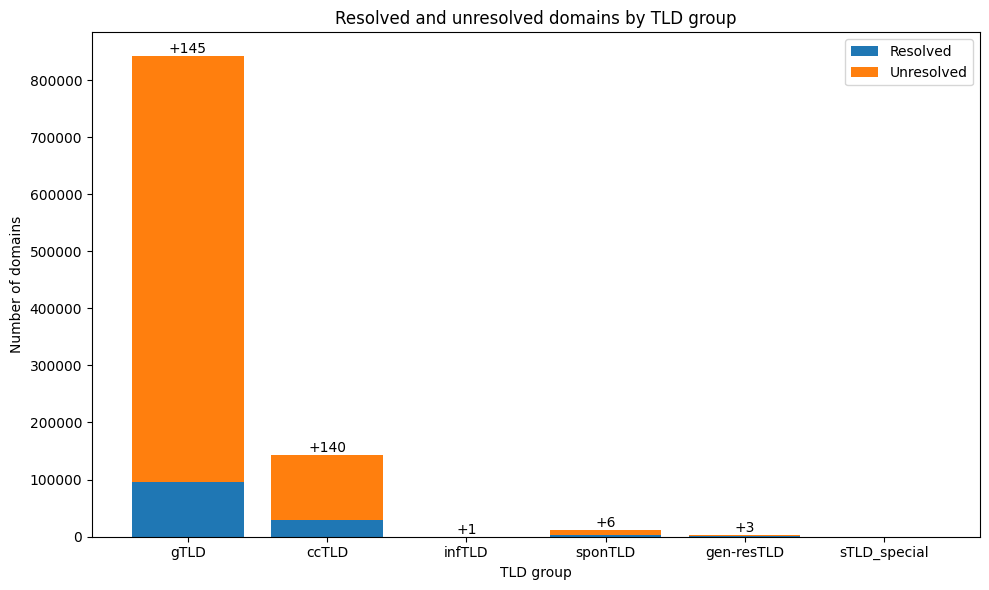

In [23]:
plot_data = plot_df[plot_df["group_code"] != "Total"].copy()

fig, ax = plt.subplots(figsize=(10, 6))

x = range(len(plot_data))

ax.bar(
    x,
    plot_data["resolved"],
    label="Resolved"
)

ax.bar(
    x,
    plot_data["unresolved"],
    bottom=plot_data["resolved"],
    label="Unresolved"
)

ax.set_xticks(list(x))
ax.set_xticklabels(plot_data["group_code"], rotation=0)
ax.set_ylabel("Number of domains")
ax.set_xlabel("TLD group")
ax.set_title("Resolved and unresolved domains by TLD group")
ax.legend()

for i, (_, row) in enumerate(plot_data.iterrows()):
    if row["resolved_extra"] > 0:
        ax.text(
            i,
            row["resolved"] + row["unresolved"],
            f'+{row["resolved_extra"]}',
            ha="center",
            va="bottom"
        )

plt.tight_layout()
plt.show()
plt.tight_layout()
plt.savefig(fig_dir / "Resolved and unresolved domains by TLD group.png", dpi=300, bbox_inches="tight")
plt.close()

#### TCB

In [24]:
categorized_names_df.head(2)

,names,tld,type
0,exo-ring.msedge.net,net,generic
1,dreamcatcher.asia.dob.sibl.support-intelligenc...,net,generic


In [26]:
resolved_summary_df = pd.concat(
    [
        gTLD_summary_df.assign(group_code="gTLD"),
        ccTLD_summary_df.assign(group_code="ccTLD"),
        genTLD_summary_df.assign(group_code="gen-resTLD"),
        infTLD_summary_df.assign(group_code="infTLD"),
        sponTLD_summary_df.assign(group_code="sponTLD"),
    ],
    ignore_index=True
)
resolved_summary_df = resolved_summary_df.merge(
    categorized_names_df[["names", "tld", "type"]].rename(columns={"names": "start_domain"}),
    on="start_domain",
    how="left"
)

In [27]:
len(resolved_summary_df)

154000

In [29]:
missing_tld_count = resolved_summary_df["tld"].isna().sum()
missing_type_count = resolved_summary_df["type"].isna().sum()

print("Missing tld:", missing_tld_count)
print("Missing Type:", missing_type_count)

Missing tld: 563
Missing Type: 563


In [34]:
# Getting TLD type information from IANA, to categorize the Datasets.
url = "https://www.iana.org/domains/root/db"
html = requests.get(url).text
soup = BeautifulSoup(html, "html.parser")

rows = []
for tr in soup.select("table tbody tr"):
    tds = tr.find_all("td")
    if len(tds) >= 3:
        a = tds[0].find("a")
        Domain = a.get_text(strip=True) if a else tds[0].get_text(strip=True)
        href = a["href"] if a and a.has_attr("href") else None
        
        punycode = None
        if href:
            filename = href.split("/")[-1]
            punycode = filename.replace(".html", "")
        else:
            full_url = None

        rows.append({
            "Domain": Domain,
            "tld": punycode,
            "type": tds[1].get_text(" ", strip=True),
            "manager": tds[2].get_text(" ", strip=True),
        })

iana_list = pd.DataFrame(rows)
print("Example of the results with reanded domain .餐厅 with its respective extracted punycode(tld)and type")
print(iana_list[iana_list["Domain"] == ".餐厅"])
print("\n")
iana_list

Example of the results with reanded domain .餐厅 with its respective extracted punycode(tld)and type
     Domain          tld     type                                     manager
1481    .餐厅  xn--imr513n  generic  Internet DotTrademark Organisation Limited




,Domain,tld,type,manager
0,.aaa,aaa,generic,"American Automobile Association, Inc."
1,.aarp,aarp,generic,AARP
2,.abarth,abarth,generic,Not assigned
3,.abb,abb,generic,ABB Ltd
4,.abbott,abbott,generic,"Abbott Laboratories, Inc."
...,...,...,...,...
1589,.zippo,zippo,generic,Not assigned
1590,.zm,zm,country-code,Zambia Information and Communications Technolo...
1591,.zone,zone,generic,"Binky Moon, LLC"
1592,.zuerich,zuerich,generic,Kanton Zürich (Canton of Zurich)


In [35]:
# extract tld from start_domain for rows missing metadata
missing_mask = resolved_summary_df["tld"].isna() | resolved_summary_df["type"].isna()

# extract tld from start_domain
resolved_summary_df.loc[missing_mask, "tld"] = (
    resolved_summary_df.loc[missing_mask, "start_domain"]
    .str.rsplit(".", n=1)
    .str[-1]
    .str.lower()
)

# temporary ascii key for matching only
temp_tld_ascii = resolved_summary_df.loc[missing_mask, "tld"]

# map Type from IANA
type_map = iana_list.set_index("tld")["type"]
resolved_summary_df.loc[missing_mask, "type"] = temp_tld_ascii.map(type_map)
resolved_summary_df = resolved_summary_df.drop(columns=["tld_ascii"], errors="ignore")


In [37]:
print("Missing TCB:", resolved_summary_df["TCB"].isna().sum())
print("Missing Type:", resolved_summary_df["type"].isna().sum())

Missing TCB: 0
Missing Type: 0


In [38]:
resolved_summary_df.head(2)

,start_domain,short_path_size,long_path_size,available_paths,avg_path_size,TCB,all_unique_ns,dependencies,group_code,tld,type
0,00.environment.api.powerplatform.com,2.0,2.0,16.0,2.000000,20,['ns1-38.azure-dns.com' 'ns1-01.azure-dns.com'...,[{'source': '00.environment.api.powerplatform....,gTLD,com,generic
1,000000book.com,2.0,10.0,16972.0,8.911619,22,['dns1.registrar-servers.com' 'dns2.registrar-...,"[{'source': '000000book.com', 'target_zone': '...",gTLD,com,generic


In [39]:
len(resolved_summary_df)

154000

In [40]:
unique_tld_count = resolved_summary_df["tld"].nunique()
print("Unique TLD count:", unique_tld_count)

Unique TLD count: 660


###### Distribution of TCB or the resolved domains.

In [41]:
tcb = resolved_summary_df["TCB"]

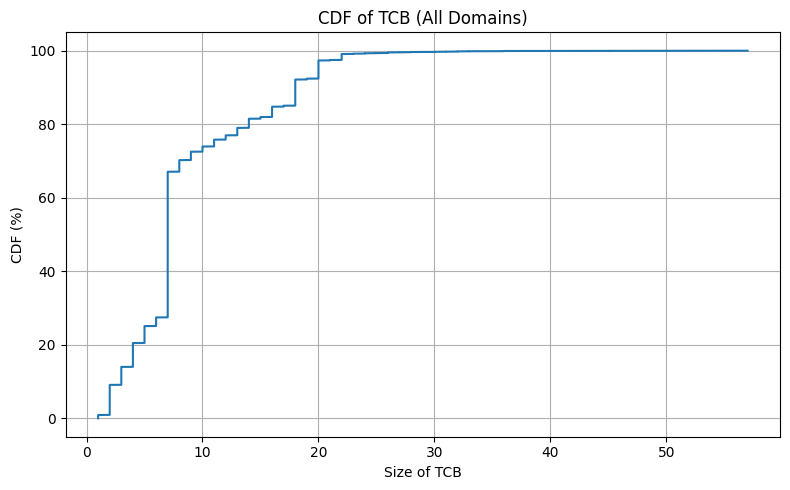

In [42]:
tcb_sorted = np.sort(tcb)
cdf = np.arange(1, len(tcb_sorted) + 1) / len(tcb_sorted)

plt.figure(figsize=(8, 5))
plt.plot(tcb_sorted, cdf * 100)

plt.xlabel("Size of TCB")
plt.ylabel("CDF (%)")
plt.title("CDF of TCB (All Domains)")

plt.grid(True)
plt.tight_layout()
plt.savefig(fig_dir / "CDF of TCB (All Domains).png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

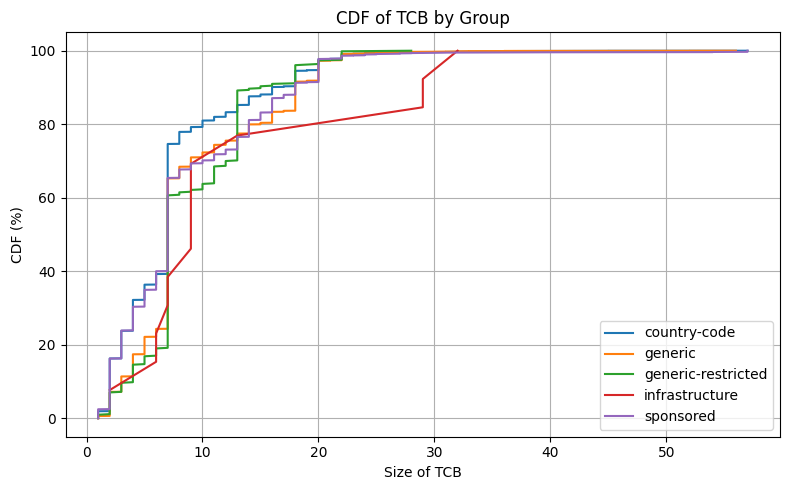

In [44]:
df = resolved_summary_df.copy()


plt.figure(figsize=(8, 5))

for group_name, group_df in df.groupby("type"):
    tcb = group_df["TCB"].dropna().to_numpy()
    
    if len(tcb) == 0:
        continue
    
    tcb_sorted = np.sort(tcb)
    cdf = np.arange(1, len(tcb_sorted) + 1) / len(tcb_sorted)
    
    plt.plot(tcb_sorted, cdf * 100, label=group_name)

plt.xlabel("Size of TCB")
plt.ylabel("CDF (%)")
plt.title("CDF of TCB by Group")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(fig_dir / "CDF of TCB by Group.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

In [45]:
mean_tcb = np.mean(tcb)
median_tcb = np.median(tcb)

x = 20
tcb = np.array(tcb)

pct_below_or_equal = np.mean(tcb <= x) * 100
pct_above = np.mean(tcb > x) * 100


print(f"mean of TCB  {mean_tcb:.2f}")
print(f"median of TCB {median_tcb:.2f}")
print(f"Percentage with TCB <= {x}: {pct_below_or_equal:.2f}%")
print(f"Percentage with TCB > {x}: {pct_above:.2f}%")

mean of TCB  8.60
median of TCB 7.00
Percentage with TCB <= 20: 97.74%
Percentage with TCB > 20: 2.26%


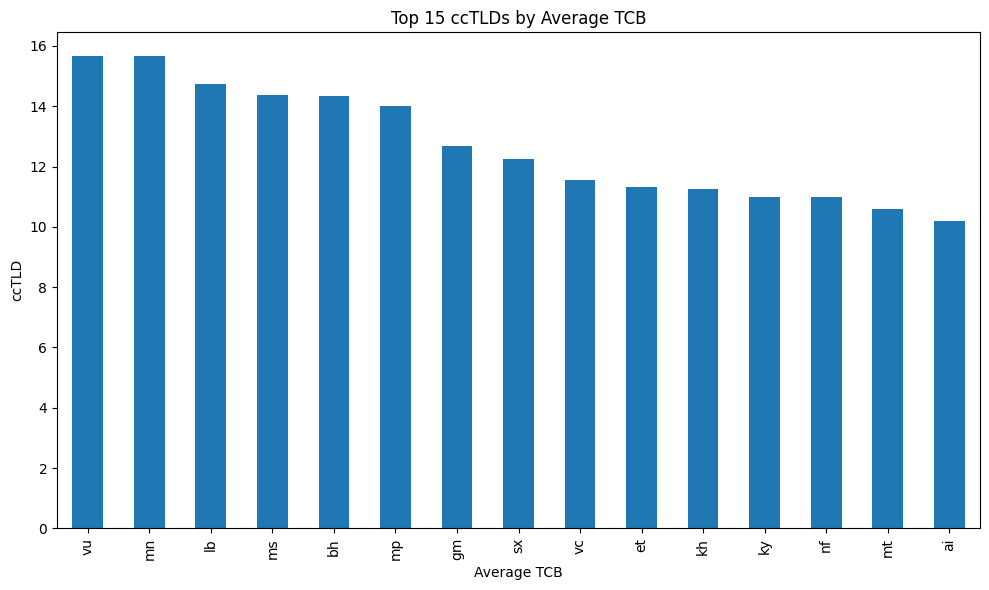

In [46]:
df = resolved_summary_df.copy()

cctld_df = df[df["group_code"] == "ccTLD"]

top15_cctld = (
    cctld_df
    .groupby("tld")["TCB"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

ax = top15_cctld.plot(kind="bar", figsize=(10, 6))


plt.xlabel("Average TCB")
plt.ylabel("ccTLD")
plt.title("Top 15 ccTLDs by Average TCB")
plt.tight_layout()
plt.savefig(fig_dir / "Top 15 ccTLDs by Average TCB.png", dpi=300, bbox_inches="tight")
plt.show()

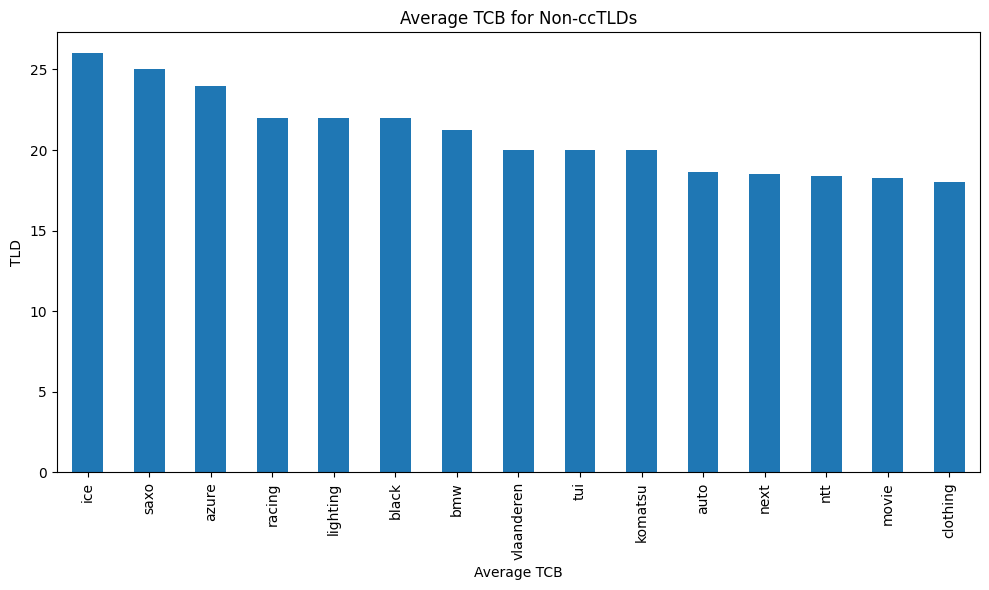

In [47]:
general_df = df[df["group_code"] != "ccTLD"]
general_tld_avg = (
    general_df
    .groupby("tld")["TCB"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

ax = general_tld_avg.plot(kind="bar", figsize=(10, 6))

plt.xlabel("Average TCB")
plt.ylabel("TLD")
plt.title("Average TCB for Non-ccTLDs")
plt.tight_layout()
plt.savefig(fig_dir / "Average TCB for Non-ccTLDs.png", dpi=300, bbox_inches="tight")
plt.show()

###### Example 114.tel

In [48]:
pd.set_option("display.max_colwidth", None)
resolved_summary_df[resolved_summary_df["start_domain"] == "114.tel"]

,start_domain,short_path_size,long_path_size,available_paths,avg_path_size,TCB,all_unique_ns,dependencies,group_code,tld,type
151651,114.tel,3.0,3.0,24.0,3.0,5,"['vip1.alidns.com', 'vip2.alidns.com', 'ns5.aliyun.com', 'ns3.aliyun.com', 'ns4.aliyun.com']","[{'via_nameservers': ['vip1.alidns.com', 'vip2.alidns.com'], 'target_zone': 'alidns.com', 'source': '114.tel'}, {'via_nameservers': ['ns5.aliyun.com', 'ns3.aliyun.com', 'ns4.aliyun.com'], 'target_zone': 'aliyun.com', 'source': 'alidns.com'}, {'via_nameservers': ['ns4.aliyun.com', 'ns3.aliyun.com', 'ns5.aliyun.com'], 'target_zone': None, 'source': 'aliyun.com'}]",sponTLD,tel,sponsored


In [49]:
pd.set_option("display.max_colwidth", None)
resolved_summary_df[resolved_summary_df["start_domain"] == "utwente.nl"]

,start_domain,short_path_size,long_path_size,available_paths,avg_path_size,TCB,all_unique_ns,dependencies,group_code,tld,type
148438,utwente.nl,1.0,1.0,12.0,1.0,3,"[""ns2.utwente.nl"",""ns3.utwente.nl"",""ns1.utwente.nl""]","[{""via_nameservers"":[""ns2.utwente.nl"",""ns3.utwente.nl"",""ns1.utwente.nl""],""target_zone"":null,""source"":""utwente.nl""}]",ccTLD,nl,country-code


In [50]:
pd.set_option("display.max_colwidth", None)
resolved_summary_df[resolved_summary_df["start_domain"] == "inventrysupport.co.uk"]

,start_domain,short_path_size,long_path_size,available_paths,avg_path_size,TCB,all_unique_ns,dependencies,group_code,tld,type
133813,inventrysupport.co.uk,2.0,3.0,100.0,2.96,18,"[""ns15.domaincontrol.com"",""ns16.domaincontrol.com"",""ans01.domaincontrol.com"",""ans02.domaincontrol.com"",""a8-67.akam.net"",""a11-64.akam.net"",""a6-66.akam.net"",""a9-67.akam.net"",""a20-65.akam.net"",""a1-245.akam.net"",""a18-67.akam.net"",""a6-67.akam.net"",""a4-67.akam.net"",""a12-67.akam.net"",""a1-67.akam.net"",""a11-67.akam.net"",""a22-67.akam.net"",""a28-67.akam.net""]","[{""via_nameservers"":[""ns15.domaincontrol.com"",""ns16.domaincontrol.com""],""target_zone"":""domaincontrol.com"",""source"":""inventrysupport.co.uk""},{""via_nameservers"":[""ans01.domaincontrol.com"",""ans02.domaincontrol.com""],""target_zone"":null,""source"":""domaincontrol.com""},{""via_nameservers"":[""a8-67.akam.net"",""a11-64.akam.net"",""a6-66.akam.net"",""a9-67.akam.net"",""a20-65.akam.net"",""a1-245.akam.net""],""target_zone"":""akam.net"",""source"":""domaincontrol.com""},{""via_nameservers"":[""a18-67.akam.net"",""a6-67.akam.net"",""a4-67.akam.net"",""a12-67.akam.net"",""a1-67.akam.net"",""a11-67.akam.net"",""a22-67.akam.net"",""a28-67.akam.net""],""target_zone"":null,""source"":""akam.net""}]",ccTLD,uk,country-code
